# Bildverarbeitung mit Neuronalen Netzen
Dies ist ein Datensatz von 50.000 32x32 (32*32 Pixel RGB) Farbtrainingsbildern und 10.000 Test Bilder, beschriftet über 10 Kategorien. 

Das Dataset besteht aus Bildern zu Flugzeugen, Autos, Vögeln, Katzen, Hirschen, Hunden, Fröschen, Pferden, Schiffen und LKWs. Zunächst wird das Dataset geladen und visualiesiert.


Trainingsbilder: (50000, 32, 32, 3)
Testbilder: (10000, 32, 32, 3)


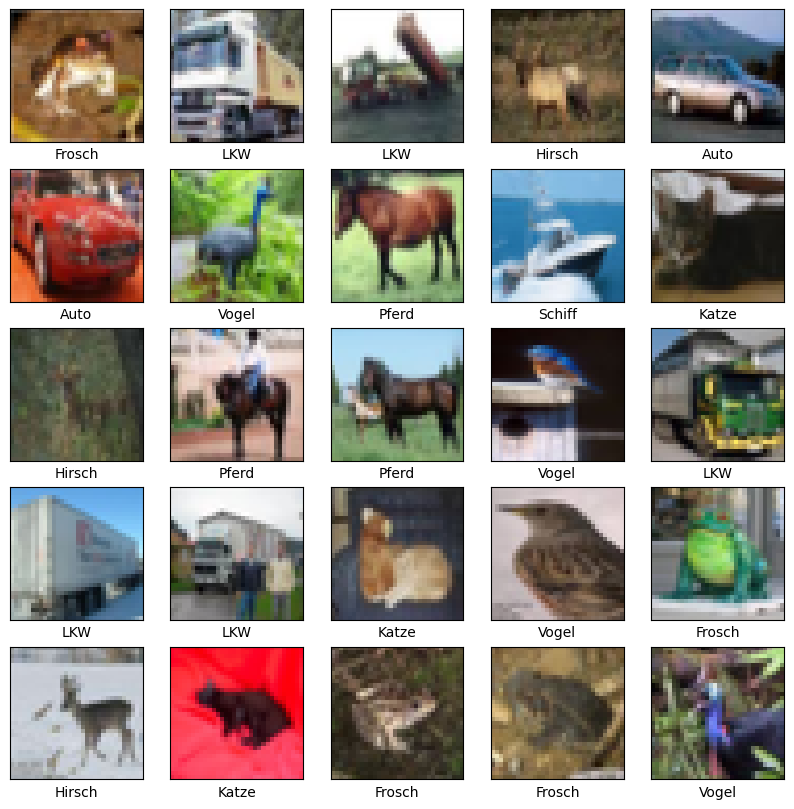

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 Datensatz laden
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Klassenbezeichnungen
class_names = ['Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch', 
               'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW']

# Datenstruktur anzeigen
print(f"Trainingsbilder: {x_train.shape}")
print(f"Testbilder: {x_test.shape}")

# Beispielbilder anzeigen
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


### Aufgabe 1
Normalisieren Sie die Daten! Leider funktionieren die bekannten Normalisierer nur im 2D Raum. Um die Daten trotzdem zu normalisieren teilen wir die Farbwerte der Pixel durch den maximal Wert (255) Nuten Sie dazu folgenden aufruf:
x_train.astype('float32') / 255.0

In [2]:
# Pixel-Werte von 0-255 auf 0-1 normalisieren
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"Normalisierte Trainingsbilder: Min={x_train.min()}, Max={x_train.max()}")


Normalisierte Trainingsbilder: Min=0.0, Max=1.0


### Aufgabe 2
Erstellen Sie ein Neuronales Netz mit folgenden Vorgaben:
- Die Eingabeschicht hat einen Input shape von (32,32,3)
- Verwenden Sie eine Convolutional-Schicht (2D) mit 32 Filtern und einem kernel_size(3,3) mit der Aktivierungsfunktion relu
- Verwenden Sie eine Polling Schicht 2D mit der Größe (2,2)
- Verwenden Sie eine weitere Convolutional-Schicht (2D) mit 64 Filtern und einem kernel_size(3,3) mit der Aktivierungsfunktion relu
- Verwenden Sie eine weitere Polling Schicht 2D mit der Größe (2,2)
- Verwenden Sie eine weitere Convolutional-Schicht (2D) mit 64 Filtern und einem kernel_size(3,3) mit der Aktivierungsfunktion relu
- Verwenden Sie eine Flatten Schicht
- Verwenden Sie eine Verdeckte Schicht mit 64 Neuronen und einer Aktivierungsfunktion mit relu
- Verwenden Sie eine Regularisierungsschicht (Dropout) mit einer Rate von 0.5
- Verwenden Sie eine Verdeckte Schicht mit 10 Neuronen und einer Aktivierungsfunktion mit softmax

Wie viele Parameter umfasst dieses Modell?


In [4]:
from keras import Sequential, layers
model=Sequential()

#Eingabeschicht
model.add(layers.Input(shape=(32,32,3)))

# Erste Convolutional-Schicht
model.add(layers.Conv2D(32,(2,2)))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

# Zweite Convolutional-Schicht
model.add(layers.Conv2D(64,(3,3)))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

# Dritte Convolutional-Schicht
model.add(layers.Conv2D(64,(3,3)))
model.add(layers.Activation('relu'))

# Flatten und Dense-Schichten
model.add(layers.Flatten())
model.add(layers.Dense(units=64))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))                    # Dropout zur Vermeidung von Overfitting
model.add(layers.Dense(10))
model.add(layers.Activation('softmax'))  # 10 Klassen

# Modellarchitektur anzeigen
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 31, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,090 (476.91 KB)

 Trainable params: 122,090 (476.91 KB)

 Non-trainable params: 0 (0.00 B)

### Aufgabe 3
Compilieren Sie das Modell. Verwenden Sie:
- Für den Optimierer 'adam'
- Für die Fehlerfunktion 'sparse_categorical_crossentropy'
- Für die metrics die accuracy

Trainieren Sie anschließend das Modell:
- Verwenden Sie 10 Epochen 
- und eine batch_size=64
- setzen Sie verbose=1  # Zeigt Fortschrittsleiste

Rufen Sie model.fit... folgendermaßen auf: history=model.fit....

In [5]:
# Modell kompilieren
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',             #Durch die Verwendung dieser Fehlerfunktion entfällt die Methode to_categorical
    metrics=['accuracy']
)

# Modell trainieren
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.3459 - loss: 1.7616 - val_accuracy: 0.4920 - val_loss: 1.3882
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4940 - loss: 1.4101 - val_accuracy: 0.5636 - val_loss: 1.2175
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.5500 - loss: 1.2721 - val_accuracy: 0.6010 - val_loss: 1.1123
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5832 - loss: 1.1847 - val_accuracy: 0.6338 - val_loss: 1.0371
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6085 - loss: 1.1178 - val_accuracy: 0.6401 - val_loss: 1.0117
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6295 - loss: 1.0584 - val_accuracy: 0.6575 - val_loss: 0.9798
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6450 - loss: 1.0160 - val_accuracy: 0.6336 - val_loss: 1.0583
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6582 - loss: 0.9747 - 

In [8]:
# Modell trainieren
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6944 - loss: 0.8770 - val_accuracy: 0.7022 - val_loss: 0.8530
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7039 - loss: 0.8527 - val_accuracy: 0.6975 - val_loss: 0.8762
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7134 - loss: 0.8288 - val_accuracy: 0.7131 - val_loss: 0.8435
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7222 - loss: 0.8072 - val_accuracy: 0.7008 - val_loss: 0.8879
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7259 - loss: 0.7814 - val_accuracy: 0.7049 - val_loss: 0.8597
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7306 - loss: 0.7696 - val_accuracy: 0.7124 - val_loss: 0.8600
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7372 - loss: 0.7464 - val_accuracy: 0.7185 - val_loss: 0.8415
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7426 - loss: 0.7315 - 

### Aufgabe 4
fit liefert verschiedene Rückgabewerte. Diese können Visualisiert werden führen Sie die nachfolgende Zelle aus!

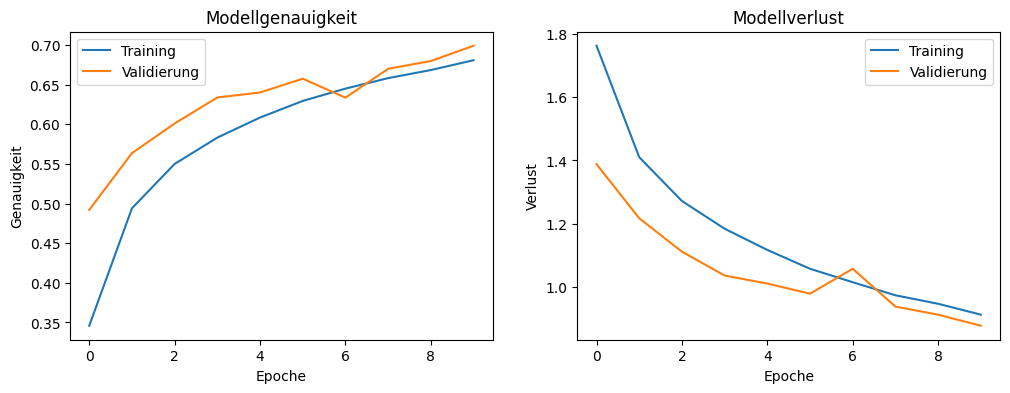

In [6]:
# Genauigkeit und Verlust plotten
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validierung')
plt.xlabel('Epoche')
plt.ylabel('Genauigkeit')
plt.legend()
plt.title('Modellgenauigkeit')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validierung')
plt.xlabel('Epoche')
plt.ylabel('Verlust')
plt.legend()
plt.title('Modellverlust')

plt.show()


In [7]:
# Modell auf Testdaten evaluieren
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest-Genauigkeit: {test_acc:.4f}")


313/313 - 2s - 5ms/step - accuracy: 0.6991 - loss: 0.8788

Test-Genauigkeit: 0.6991


### Aufgabe 5
Lassen Sie uns die Vorhersage des Neuronalen Netz mit den realen Werten vergleichen. Wo sind Fehler aufgetreten? Führen Sie die nachfolgende Zelle aus.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


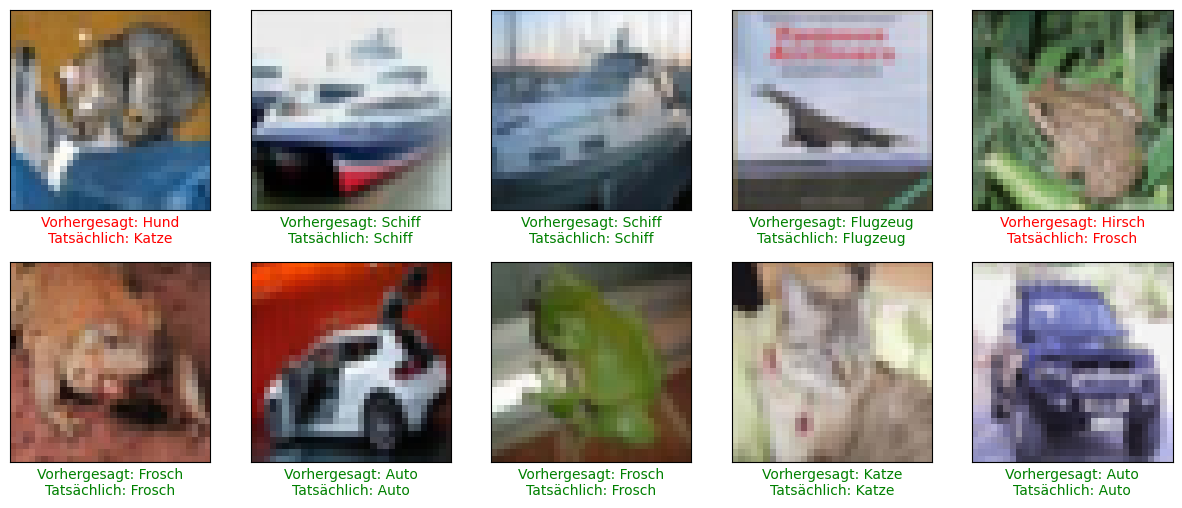

In [8]:
# Vorhersagen für Testbilder
predictions = model.predict(x_test[:10])

# Ergebnisse visualisieren
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i][0]
    
    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f"Vorhergesagt: {class_names[predicted_label]}\n"
               f"Tatsächlich: {class_names[true_label]}", 
               color=color)
plt.show()
